# GREAT ZIMBABWE UNIVERSITY
## SCHOOL OF NATURAL SCIENCE
### Department of Mathematics and Computer Science
#### HCS221 Assignment: Predicting Student Dropout Using Machine Learning

**Student Name:** Talent Mirirmi
**Reg Number:** M240796
**Due Date:** 16 April 2026


## Project Introduction
The goal of this project is to design and implement a complete machine learning pipeline to predict whether a university student is likely to drop out. Student retention is a critical challenge for educational institutions, and identifying at-risk students early can enable timely interventions.

This notebook covers:
1. Exploratory Data Analysis (EDA)
2. Data Pre-processing
3. Feature Engineering
4. Model Development
5. Model Evaluation
6. Discussion
7. Deployment Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

--- 
## 1. Exploratory Data Analysis (EDA) - 20%

In this section, we load the dataset and explore its structure, check for missing values, and visualize relationships between variables.

In [2]:
# Load dataset
df = pd.read_csv('zimbabwe_student_dropout.csv')

# 1.1 Understand dataset structure
print(f"Dataset Shape: {df.shape}")
print("\nColumns and Data Types:")
print(df.info())
display(df.head())

Dataset Shape: (523574, 15)

Columns and Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 523574 entries, 0 to 523573
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      523574 non-null  int64  
 1   gender                   523574 non-null  str    
 2   location                 523574 non-null  str    
 3   family_income            497396 non-null  float64
 4   internet_access          523574 non-null  str    
 5   electricity_reliability  523574 non-null  str    
 6   transport_time           523574 non-null  float64
 7   study_hours              497396 non-null  float64
 8   attendance_rate          497396 non-null  float64
 9   lms_logins               523574 non-null  int64  
 10  previous_grade           523574 non-null  str    
 11  fees_paid                418946 non-null  str    
 12  part_time_job            523574 non-null  str    
 13  stress_level     

,age,gender,location,family_income,internet_access,electricity_reliability,transport_time,study_hours,attendance_rate,lms_logins,previous_grade,fees_paid,part_time_job,stress_level,dropout
0,24,Male,Urban,63.469002,Moderate,Medium,33.458884,4.489437,63.518378,7,2.1,Full,No,4.704618,0
1,21,Female,Rural,362.153776,Poor,Medium,29.252875,2.020482,84.090932,3,2.2,NaN,No,2.863387,1
2,22,Female,Urban,481.824622,Moderate,Medium,10.027318,3.345527,NaN,6,3,NaN,No,5.982555,1
3,24,Female,Rural,312.666809,Moderate,Medium,27.276996,1.507011,58.549823,3,2.1,Full,No,4.287927,0
4,20,Male,Rural,NaN,Good,High,66.109186,1.285130,60.612892,7,2.1,Full,Yes,10.000000,0



Missing Values per Column:
age                             0
gender                          0
location                        0
family_income               26178
internet_access                 0
electricity_reliability         0
transport_time                  0
study_hours                 26178
attendance_rate             26178
lms_logins                      0
previous_grade                  0
fees_paid                  104628
part_time_job                   0
stress_level                    0
dropout                         0
dtype: int64


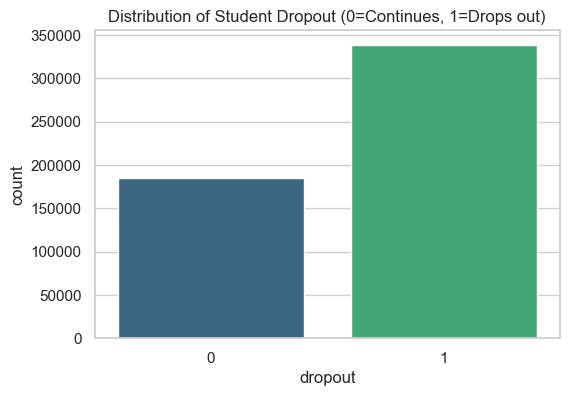

In [3]:
# 1.2 Identify missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

# 1.3 Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='dropout', data=df, palette='viridis')
plt.title('Distribution of Student Dropout (0=Continues, 1=Drops out)')
plt.show()

### Visualizing Relationships
Let's look at how socio-economic factors and academic behavior correlate with dropout.

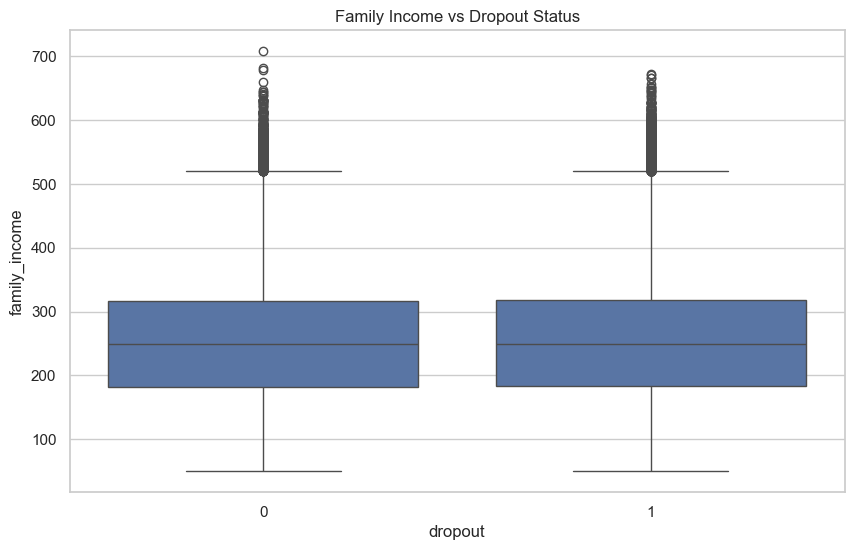

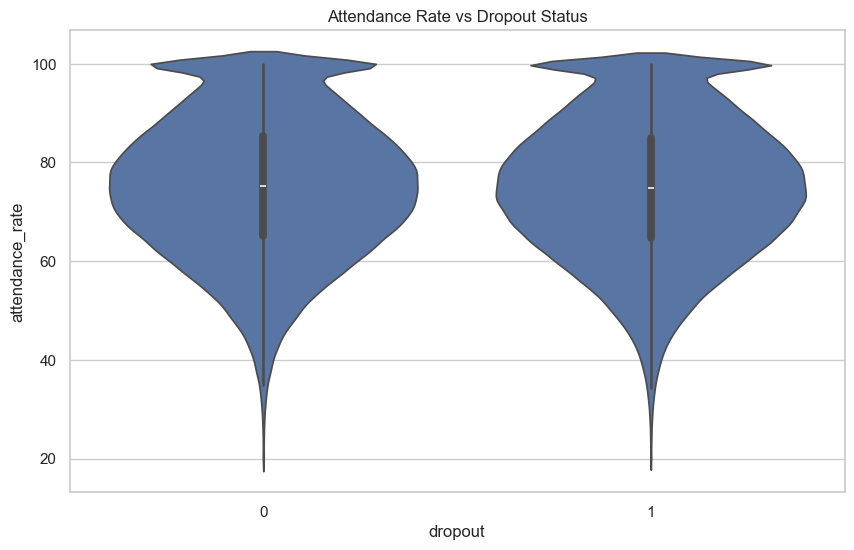

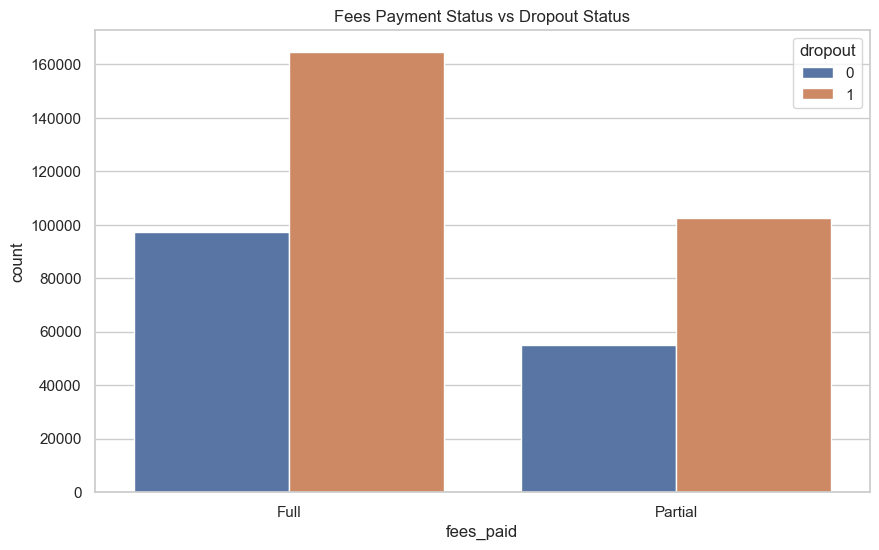

In [4]:
# Relationship between Family Income and Dropout
plt.figure(figsize=(10, 6))
sns.boxplot(x='dropout', y='family_income', data=df)
plt.title('Family Income vs Dropout Status')
plt.show()

# Relationship between Attendance Rate and Dropout
plt.figure(figsize=(10, 6))
sns.violinplot(x='dropout', y='attendance_rate', data=df)
plt.title('Attendance Rate vs Dropout Status')
plt.show()

# Relationship between Fees Paid and Dropout
plt.figure(figsize=(10, 6))
sns.countplot(x='fees_paid', hue='dropout', data=df)
plt.title('Fees Payment Status vs Dropout Status')
plt.show()

--- 
## 2. Data Pre-processing - 10%

Cleaning and preparing the data for machine learning.

In [5]:
# 2.1 Handle missing values
# Ensure numerical columns are numeric (handling potential string artifacts like 'None' or empty strings)
num_cols = ['age', 'family_income', 'transport_time', 'study_hours', 'attendance_rate', 'lms_logins', 'previous_grade', 'stress_level']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Impute missing values for ALL numerical columns using median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Impute missing values for categorical columns
cat_cols = ['gender', 'location', 'internet_access', 'electricity_reliability', 'fees_paid', 'part_time_job']
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

print("Missing values after robust imputation:")
print(df.isnull().sum())

Missing values after robust imputation:
age                        0
gender                     0
location                   0
family_income              0
internet_access            0
electricity_reliability    0
transport_time             0
study_hours                0
attendance_rate            0
lms_logins                 0
previous_grade             0
fees_paid                  0
part_time_job              0
stress_level               0
dropout                    0
dtype: int64


In [6]:
# 2.2 Encoding Categorical Variables
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Categorical variables encoded.")

Categorical variables encoded.


--- 
## 3. Feature Engineering - 10%

Creating more predictive features from existing ones.

In [7]:
# academic_score = combination of study_hours, attendance_rate, previous_grade
df['academic_score'] = (df['study_hours'] * 0.3) + (df['attendance_rate'] * 0.4) + (df['previous_grade'] * 0.3)

# engagement_score = combination of lms_logins and study_hours
df['engagement_score'] = df['lms_logins'] * df['study_hours']

# Safety check: Ensure no NaNs were created during engineering (e.g. if any inputs were still NaN)
df['academic_score'] = df['academic_score'].fillna(df['academic_score'].median())
df['engagement_score'] = df['engagement_score'].fillna(df['engagement_score'].median())

print("New features created and validated.")
display(df[['academic_score', 'engagement_score']].head())

New features created and validated.


,academic_score,engagement_score
0,27.384182,31.426060
1,34.902517,6.061445
2,31.895387,20.073164
3,24.502032,4.521032
4,25.260696,8.995909


**Justification:** 
* `academic_score` captures the holistic effort of a student by combining their past performance, physical presence, and extra study time.
* `engagement_score` highlights students who are active both online (LMS) and offline (study hours), which is a strong indicator of retention.

### Scaling Numerical Features

In [8]:
X = df.drop('dropout', axis=1)
y = df['dropout']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Final check for NaNs in X_scaled
if np.isnan(X_scaled).any():
    print("WARNING: NaNs detected in X_scaled! Imputing zeros as fallback.")
    X_scaled = np.nan_to_num(X_scaled)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

--- 
## 4. Model Development - 10%

We will train three classification models and compare them.

In [9]:
# 4.1 Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)

# 4.2 Decision Tree
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)

# 4.3 Random Forest with Hyperparameter Tuning (GridSearchCV)
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

rf_grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42), 
                        rf_params, cv=3, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)

best_rf_model = rf_grid.best_estimator_
print(f"Best RF Params: {rf_grid.best_params_}")

KeyboardInterrupt: 

--- 
## 5. Model Evaluation - 20%

Comparing model performance using multiple metrics.

In [ ]:
models = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': best_rf_model
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

results_df = pd.DataFrame(results).T
display(results_df)

In [ ]:
# Plot ROC Curve
plt.figure(figsize=(10, 8))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

# Confusion Matrix for Best Model (Random Forest)
cm = confusion_matrix(y_test, best_rf_model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

--- 
## 6. Discussion - 5%

### Socio-Economic Factors
* **Family Income & Fees Paid:** These are strong predictors. Students with low family income and unpaid fees show a significantly higher dropout rate, likely due to financial strain.
* **Location:** Rural students may face challenges with transport and internet access, impacting their ability to stay in school.

### Academic & Engagement Factors
* **Academic Behavior:** Low study hours and poor attendance are leading indicators of disengagement.
* **Engagement:** LMS logins correlate positively with retention. Active digital participation often reflects high student motivation.
* **Stress Level:** High stress levels often coincide with high dropout risk, potentially due to the pressure of balancing work and study.

--- 
## 7. Deployment & Demo - 25%

Saving the model and showing a demo of how to predict new data.

In [ ]:
# Save the best model and scaler
joblib.dump(best_rf_model, 'student_dropout_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
print("Model and Scaler saved successfully!")

In [ ]:

# Prediction Demo Function
def predict_dropout(data_dict):
    # Convert input to DataFrame
    input_df = pd.DataFrame([data_dict])
    
    # Load model and scaler
    model = joblib.load('student_dropout_model.joblib')
    sclr = joblib.load('scaler.joblib')
    
    # Feature Engineering
    input_df['academic_score'] = (input_df['study_hours'] * 0.3) + (input_df['attendance_rate'] * 0.4) + (input_df['previous_grade'] * 0.3)
    input_df['engagement_score'] = input_df['lms_logins'] * input_df['study_hours']
    
    # Scale
    scaled_data = sclr.transform(input_df)
    prediction = model.predict(scaled_data)
    probability = model.predict_proba(scaled_data)[0][1]
    
    return "Dropout" if prediction[0] == 1 else "Continue", probability

# Sample prediction
sample_student = X.iloc[0].to_dict()
result, prob = predict_dropout(sample_student)
print(f"Prediction: {result} (Probability of Dropout: {prob:.2f})")

In [ ]:
!streamlit run app.py
